# Previsão de preços de casas — contexto, objetivo e análise exploratória

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Contexto
Foi Revebido dados anonimizados de imóveis da região de Seattle. Um arquivo contém características e preços de vendas históricas; outro descreve a população por CEP; um terceiro apresenta 100 exemplos sem preço para os quais produziremos estimativas.

## Objetivo
Entender a qualidade dos dados, reconhecer informações que podem ajudar a prever preços e registrar limitações antes de construir o modelo. Nesta etapa ainda não treinamos um modelo nem medimos sua precisão.

## Por que fazer EDA?
EDA significa **análise exploratória de dados**. Ela ajuda a descobrir possíveis erros, entender diferenças entre os imóveis e evitar decisões baseadas apenas em suposições. Um imóvel muito caro, por exemplo, não deve ser removido sem investigar suas características.

**Execução:** selecione o Python da pasta `.venv` no Jupyter e execute as células da pasta "notebook" em ordem. Os arquivos originais são preservados. Os nomes das colunas originais são mantidos para conferir a fonte. Resultados vão para `reports/`.


In [1]:
# Prepara as bibliotecas e as pastas da análise.
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as exibir

# Aceita execução na raiz ou na pasta notebooks.
PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "raw").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
if not ((PASTA_PROJETO / "data" / "raw").is_dir()):
    raise ValueError("Execute na raiz ou em notebooks.")

PASTA_ORIGINAIS = PASTA_PROJETO / "data" / "raw"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_TRATADOS = PASTA_PROJETO / "data" / "processed"
for pasta in [PASTA_GRAFICOS, PASTA_RESULTADOS, PASTA_TRATADOS]:
    pasta.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True})
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)

Python: 3.13.15
pandas: 3.0.5


**O que o resultado mostra**

A saída identifica as versões do Python e pandas usadas para executar a análise. Isso documenta o ambiente, não um resultado sobre o mercado imobiliário.

**Por que fizemos esta análise e o que decidimos**

Preparamos bibliotecas e pastas para repetir a análise com os mesmos arquivos. Avisos sobre cache temporário do Matplotlib dizem respeito a arquivos auxiliares; devem ser distinguidos de erros que interrompem os cálculos.

## Visualização dos datasets

In [2]:
# Mostra as primeiras vendas com as colunas originais.
imoveis = pd.read_csv(PASTA_ORIGINAIS / "kc_house_data.csv", dtype={"id": "string", "zipcode": "string"})
exibir(imoveis.head(10))

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


**O que o resultado mostra**

A prévia mostra as dez primeiras vendas com preço e características. Todas as colunas originais permanecem visíveis.

**Por que fizemos esta análise e o que decidimos**

Conferimos a estrutura do arquivo antes da exploração. Dez linhas não representam todo o mercado; as estatísticas seguintes utilizam o histórico completo.

In [3]:
# Mostra as primeiras regiões com todas as colunas.
demografia = pd.read_csv(PASTA_ORIGINAIS / "zipcode_demographics.csv", dtype={"zipcode": "string"})
exibir(demografia.head(10))

,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,farm_ppltn_qty,non_farm_qty,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt,edctn_less_than_9_qty,edctn_9_12_qty,edctn_high_schl_qty,edctn_some_clg_qty,edctn_assoc_dgre_qty,edctn_bchlr_dgre_qty,edctn_prfsnl_qty,per_urbn,per_sbrbn,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,zipcode
0,38249.0,37394.0,0.0,0.0,855.0,66051.0,25219.0,192000.0,437.0,2301.0,7135.0,7787.0,2202.0,4964.0,1783.0,97.0,0.0,0.0,2.0,1.0,6.0,18.0,20.0,5.0,12.0,4.0,98042
1,22036.0,22036.0,0.0,0.0,0.0,91904.0,53799.0,573900.0,149.0,404.0,1441.0,2826.0,673.0,5961.0,4878.0,100.0,0.0,0.0,0.0,0.0,1.0,6.0,12.0,3.0,27.0,22.0,98040
2,18194.0,18194.0,0.0,0.0,0.0,61813.0,31765.0,246600.0,269.0,905.0,2386.0,3703.0,1211.0,3547.0,1762.0,100.0,0.0,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,98028
3,21956.0,21956.0,0.0,0.0,0.0,47461.0,22158.0,175400.0,925.0,1773.0,4530.0,4630.0,1277.0,2688.0,952.0,100.0,0.0,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,98178
4,22814.0,22814.0,0.0,0.0,0.0,48606.0,28398.0,252600.0,599.0,1148.0,3077.0,4085.0,1326.0,5341.0,2818.0,100.0,0.0,0.0,0.0,2.0,5.0,13.0,17.0,5.0,23.0,12.0,98007
5,9533.0,9533.0,0.0,0.0,0.0,37411.0,22044.0,167200.0,364.0,925.0,2017.0,2337.0,594.0,956.0,281.0,100.0,0.0,0.0,0.0,3.0,9.0,21.0,24.0,6.0,10.0,2.0,98148
6,43121.0,43121.0,0.0,0.0,0.0,41743.0,23137.0,204200.0,1254.0,3055.0,7413.0,9749.0,2896.0,7707.0,3369.0,100.0,0.0,0.0,0.0,2.0,7.0,17.0,22.0,6.0,17.0,7.0,98133
7,19435.0,19435.0,0.0,0.0,0.0,47519.0,25844.0,200000.0,964.0,1516.0,3123.0,3812.0,1145.0,3290.0,1485.0,100.0,0.0,0.0,0.0,4.0,7.0,16.0,19.0,5.0,16.0,7.0,98126
8,25495.0,25245.0,0.0,0.0,250.0,60534.0,24011.0,168400.0,475.0,1828.0,5293.0,5336.0,1687.0,2725.0,856.0,99.0,0.0,0.0,0.0,1.0,7.0,20.0,20.0,6.0,10.0,3.0,98001
9,43263.0,43263.0,0.0,0.0,0.0,58475.0,34026.0,282800.0,370.0,1090.0,3667.0,6852.0,1951.0,13103.0,8891.0,100.0,0.0,0.0,0.0,0.0,2.0,8.0,15.0,4.0,30.0,20.0,98115


**O que o resultado mostra**

Cada linha da prévia representa uma região identificada pelo CEP. A população, primeira coluna do arquivo, continua visível.

**Por que fizemos esta análise e o que decidimos**

Essa leitura distingue informações de uma região de características de uma casa. Renda regional não é a renda de cada morador. A prévia não confirma definições nem data dos indicadores.

In [4]:
# Mostra os primeiros exemplos sem preço.
exemplos_futuros = pd.read_csv(PASTA_ORIGINAIS / "future_unseen_examples.csv", dtype={"zipcode": "string"})
exibir(exemplos_futuros.head(10))

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,4,1.00,1680,5043,1.5,0,0,4,6,1680,0,1911,0,98118,47.5354,-122.273,1560,5765
1,3,2.50,2220,6380,1.5,0,0,4,8,1660,560,1931,0,98115,47.6974,-122.313,950,6380
2,3,2.25,1630,10962,1.0,0,0,4,8,1100,530,1977,0,98030,47.3801,-122.166,1830,8470
3,5,2.50,1710,9720,2.0,0,0,4,8,1710,0,1974,0,98005,47.5903,-122.157,2270,9672
4,2,1.00,850,6370,1.0,0,0,3,6,850,0,1951,0,98126,47.5198,-122.373,850,5170
5,4,2.75,2630,4501,2.0,0,0,3,8,2630,0,2015,0,98028,47.7748,-122.244,2380,4599
6,4,1.75,2290,7380,1.0,0,0,3,7,1390,900,1963,0,98178,47.5034,-122.245,1170,7381
7,4,2.00,1730,9139,2.0,0,0,3,8,1730,0,1957,0,98125,47.7181,-122.316,1410,7311
8,3,1.75,2190,8500,1.0,0,0,4,9,2190,0,1957,0,98112,47.6400,-122.285,2850,8868
9,3,1.75,1850,22767,1.5,0,4,5,6,1850,0,1908,0,98074,47.6144,-122.067,2700,17906


**O que o resultado mostra**

A prévia contém características dos imóveis que receberão previsões, sem preço. A coluna de quartos permanece disponível e não foi transformada em índice.

**Por que fizemos esta análise e o que decidimos**

Conferimos o formato que o modelo receberá na prática. Dez linhas não resumem todos os exemplos; as verificações seguintes usam as 100 linhas.

## O que cada coluna pode significar?

**As descrições abaixo são suposições, não um dicionário confirmado pelo fornecedor.** Os nomes, valores e contexto ajudam a formular hipóteses, mas não comprovam como as informações foram coletadas.

| Coluna original | Interpretação provável e cuidados |
|---|---|
| `id` | Identificador do imóvel. Não é uma medida; repetições podem representar revendas. |
| `date` | Data associada à venda ou ao registro.  |
| `price` | Preço a prever em USD, por premissa do projeto, sem confirmação explícita da fonte. |
| `bedrooms` | Quantidade de quartos.  |
| `bathrooms` | Quantidade de banheiros.  |
| `sqft_living` | Área habitável. O nome sugere pés quadrados |
| `sqft_lot` | Área do terreno.  |
| `floors` | Número de pavimentos. |
| `waterfront` | Indicador de imóvel junto à água.  |
| `view` | Avaliação da vista.  |
| `condition` | Avaliação da conservação.  |
| `grade` | Classificação da qualidade de construção e acabamento.  |
| `sqft_above` | Área acima do solo.  |
| `sqft_basement` | Área do porão.  |
| `yr_built` | Ano de construção.  |
| `yr_renovated` | Ano de reforma.  |
| `zipcode` | CEP, identificador da região usado para conectar as tabelas. |
| `lat` | Latitude, posição norte–sul.  |
| `long` | Longitude, posição leste–oeste.  |
| `sqft_living15` | Outra medida de área habitável. O significado de 15 não foi documentado. |
| `sqft_lot15` | Outra medida de área de terreno. Não assumir que 15 seja ano ou número de vizinhos. |
| `ppltn_qty` | Quantidade de população. |
| `urbn_ppltn_qty` | Quantidade de população classificada como urbana. |
| `sbrbn_ppltn_qty` | Quantidade de população classificada como suburbana. |
| `farm_ppltn_qty` | Quantidade de população em uma categoria agrícola. |
| `non_farm_qty` | Quantidade de população em uma categoria não agrícola. |
| `medn_hshld_incm_amt` | Renda mediana dos domicílios: valor central das rendas ordenadas. |
| `medn_incm_per_prsn_amt` | Indicador de renda por pessoa; definição estatística a confirmar. |
| `hous_val_amt` | Indicador de valor habitacional |
| `edctn_less_than_9_qty` | Contagem de pessoas com escolaridade abaixo do 9º ano. |
| `edctn_9_12_qty` | Contagem em uma faixa de escolaridade do 9º ao 12º ano. |
| `edctn_high_schl_qty` | Contagem de uma categoria de ensino médio. |
| `edctn_some_clg_qty` | Contagem de pessoas com alguma passagem pelo ensino superior. |
| `edctn_assoc_dgre_qty` | Contagem de formação do tipo associate degree nos EUA. |
| `edctn_bchlr_dgre_qty` | Contagem de formação do tipo bachelor's degree nos EUA. |
| `edctn_prfsnl_qty` | Contagem de uma categoria de formação profissional avançada. |
| `per_urbn` | Percentual de uma categoria de população urbana. |
| `per_sbrbn` | Percentual de uma categoria de população suburbana. |
| `per_farm` | Percentual de uma categoria populacional agrícola. |
| `per_non_farm` | Percentual de uma categoria populacional não agrícola. |
| `per_less_than_9` | Percentual de escolaridade abaixo do 9º ano. |
| `per_9_to_12` | Percentual de uma categoria escolar do 9º ao 12º ano. |
| `per_hsd` | Percentual de uma categoria de conclusão do ensino médio. |
| `per_some_clg` | Percentual de uma categoria de passagem pelo ensino superior. |
| `per_assoc` | Percentual de formação do tipo associate degree. |
| `per_bchlr` | Percentual de formação do tipo bachelor's degree. |
| `per_prfsnl` | Percentual de uma categoria de formação profissional avançada. |

O histórico tem 21 colunas. Os exemplos futuros não incluem `id`, `date` e `price`. A demografia contém o CEP e 26 indicadores.

A hipótese sobre `grade` e `condition` é compatível com o [glossário oficial de King County](https://info.kingcounty.gov/assessor/esales/Glossary.aspx?type=r), mas essa referência não comprova a origem do arquivo anonimizado.

## 1. Leitura e diagnóstico estrutural

Verificamos os três arquivos completos. Identificador e CEP são texto porque não representam quantidades. Nenhuma separação de treino, validação ou teste será feita nesta etapa.

In [5]:
# Conta linhas, ausências e cópias completas.
imoveis = pd.read_csv(PASTA_ORIGINAIS / "kc_house_data.csv", dtype={"id": "string", "zipcode": "string"})
demografia = pd.read_csv(PASTA_ORIGINAIS / "zipcode_demographics.csv", dtype={"zipcode": "string"})
exemplos_futuros = pd.read_csv(PASTA_ORIGINAIS / "future_unseen_examples.csv", dtype={"zipcode": "string"})
tabelas = {"imoveis": imoveis, "demografia": demografia, "futuros": exemplos_futuros}

# Resume a integridade dos arquivos.
visao_geral = pd.DataFrame([
    {"arquivo": nome, "linhas": len(tabela), "colunas": tabela.shape[1],
     "celulas_ausentes": int(tabela.isna().sum().sum()),
     "linhas_duplicadas": int(tabela.duplicated().sum())}
    for nome, tabela in tabelas.items()
])
visao_geral.to_csv(PASTA_RESULTADOS / "eda_overview.csv", index=False)
exibir(visao_geral)

,arquivo,linhas,colunas,celulas_ausentes,linhas_duplicadas
0,imoveis,21613,21,0,0
1,demografia,70,27,0,0
2,futuros,100,18,0,0


**O que o resultado mostra**

Há 21.613 registros históricos, 70 registros demográficos e 100 exemplos futuros. Não foram encontrados campos vazios reconhecidos pelo pandas nem linhas iguais em todas as colunas.

**Por que fizemos esta análise e o que decidimos**

Contar registros e ausências mostra o tamanho do trabalho e possíveis problemas básicos. Isso não garante dados perfeitos: zeros podem representar falta de informação e um imóvel pode aparecer em vendas diferentes.

In [6]:
# Resume tipos e preenchimento das colunas.
# Prepara o diagnóstico por coluna para cada arquivo.
diagnosticos = {}
for nome, tabela in tabelas.items():
    diagnostico = pd.DataFrame({
        "tipo": tabela.dtypes.astype(str),
        "ausentes": tabela.isna().sum(),
        "ausentes_pct": tabela.isna().mean().mul(100),
    }).rename_axis("coluna").reset_index()
    diagnostico.insert(0, "arquivo", nome)
    diagnosticos[nome] = diagnostico
pd.concat(diagnosticos.values(), ignore_index=True).to_csv(PASTA_RESULTADOS / "eda_schema.csv", index=False)
exibir(diagnosticos["imoveis"])

,arquivo,coluna,tipo,ausentes,ausentes_pct
0,imoveis,id,string,0,0.0
1,imoveis,date,str,0,0.0
2,imoveis,price,float64,0,0.0
3,imoveis,bedrooms,int64,0,0.0
4,imoveis,bathrooms,float64,0,0.0
5,imoveis,sqft_living,int64,0,0.0
6,imoveis,sqft_lot,int64,0,0.0
7,imoveis,floors,float64,0,0.0
8,imoveis,waterfront,int64,0,0.0
9,imoveis,view,int64,0,0.0


**O que o resultado mostra**

Os campos do histórico estão preenchidos. Identificador e CEP são texto; banheiros e pavimentos preservam frações. A data ainda será convertida para comparar períodos.

**Por que fizemos esta análise e o que decidimos**

Verificamos tipos para evitar perda de informação. Na tabela, string/str significa texto, int64 significa inteiro e float64 permite decimais. Um código numérico como grade pode ser uma classificação, não uma quantidade.

In [7]:
# Confere o formato dos indicadores regionais.
# Inspeciona os tipos dos indicadores por CEP.
exibir(diagnosticos["demografia"])

,arquivo,coluna,tipo,ausentes,ausentes_pct
0,demografia,ppltn_qty,float64,0,0.0
1,demografia,urbn_ppltn_qty,float64,0,0.0
2,demografia,sbrbn_ppltn_qty,float64,0,0.0
3,demografia,farm_ppltn_qty,float64,0,0.0
4,demografia,non_farm_qty,float64,0,0.0
5,demografia,medn_hshld_incm_amt,float64,0,0.0
6,demografia,medn_incm_per_prsn_amt,float64,0,0.0
7,demografia,hous_val_amt,float64,0,0.0
8,demografia,edctn_less_than_9_qty,float64,0,0.0
9,demografia,edctn_9_12_qty,float64,0,0.0


**O que o resultado mostra**

A demografia contém 26 indicadores numéricos e um CEP textual, sem ausências detectadas.

**Por que fizemos esta análise e o que decidimos**

Essa checagem prepara a conexão entre os arquivos. Ser numérico e estar preenchido não confirma unidade, significado ou atualidade de um indicador; essas dúvidas continuam abertas.

In [8]:
# Confere as entradas disponíveis para previsão.
# Confere o esquema das entradas de inferência.
exibir(diagnosticos["futuros"])

,arquivo,coluna,tipo,ausentes,ausentes_pct
0,futuros,bedrooms,int64,0,0.0
1,futuros,bathrooms,float64,0,0.0
2,futuros,sqft_living,int64,0,0.0
3,futuros,sqft_lot,int64,0,0.0
4,futuros,floors,float64,0,0.0
5,futuros,waterfront,int64,0,0.0
6,futuros,view,int64,0,0.0
7,futuros,condition,int64,0,0.0
8,futuros,grade,int64,0,0.0
9,futuros,sqft_above,int64,0,0.0


**O que o resultado mostra**

Os exemplos futuros têm 18 características preenchidas, incluindo CEP e valores fracionários.

**Por que fizemos esta análise e o que decidimos**

Precisamos saber quais informações estarão disponíveis ao prever. O modelo não deverá depender de campos exclusivos do histórico. Ausências e categorias novas ainda exigirão tratamento em uma aplicação real.

In [9]:
# Compara arquivos, datas e identificadores.
# Compara as entradas disponíveis na inferência.
colunas_so_no_historico = sorted(set(imoveis.columns) - set(exemplos_futuros.columns))
colunas_so_nos_futuros = sorted(set(exemplos_futuros.columns) - set(imoveis.columns))
print("Somente nos dados rotulados:", colunas_so_no_historico)
print("Somente nos exemplos futuros:", colunas_so_nos_futuros)
if not ("price" in imoveis and "price" not in exemplos_futuros):
    raise ValueError('O histórico precisa conter price e os exemplos futuros não devem conter o alvo.')
if colunas_so_nos_futuros:
    raise ValueError("Investigar colunas inesperadas nos exemplos futuros.")

datas_vendas = pd.to_datetime(imoveis["date"], format="%Y%m%dT%H%M%S", errors="coerce")
print("Datas inválidas:", int(datas_vendas.isna().sum()))
print("Período:", datas_vendas.min(), "a", datas_vendas.max())
print("IDs ausentes:", int(imoveis["id"].isna().sum()))
print("Registros além do primeiro por ID:", int(imoveis["id"].duplicated().sum()))
print("IDs com mais de um registro:", int(imoveis["id"].value_counts().gt(1).sum()))
if not (datas_vendas.notna().all() and imoveis["id"].notna().all()):
    raise ValueError('Existem datas ou identificadores ausentes ou inválidos.')


Somente nos dados rotulados: ['date', 'id', 'price']
Somente nos exemplos futuros: []
Datas inválidas: 0
Período: 2014-05-02 00:00:00 a 2015-05-27 00:00:00
IDs ausentes: 0
Registros além do primeiro por ID: 177
IDs com mais de um registro: 176


**O que o resultado mostra**

Somente o histórico tem id, date e price. A ausência de price nos exemplos futuros é esperada, pois queremos prevê-lo. As datas válidas vão de 02/05/2014 a 27/05/2015. Há 176 IDs repetidos e 177 linhas além da primeira ocorrência desses imóveis.

**Por que fizemos esta análise e o que decidimos**

A comparação evita exigir entradas indisponíveis. IDs repetidos podem indicar revendas; não comprovam erros. Usaremos ID para acompanhar imóveis e data para avaliar, na modelagem, como separar os dados, sem utilizá-los inicialmente como entradas do modelo.

## 2. Cobertura demográfica e possíveis sobreposições

A unicidade do CEP demográfico é necessária para um merge muitos-para-um. A cobertura não garante que os indicadores estavam disponíveis na data da venda. Também verificamos coincidências exatas das características dos exemplos futuros com os registros históricos; uma coincidência não comprova identidade, mas limita a interpretação do termo “não vistos”. Não consultamos preços para essa comparação.

In [10]:
# Procura CEPs vazios ou duplicados.
print("CEPs demográficos duplicados:", int(demografia["zipcode"].duplicated().sum()))
print("CEPs demográficos ausentes:", int(demografia["zipcode"].isna().sum()))

CEPs demográficos duplicados: 0
CEPs demográficos ausentes: 0


**O que o resultado mostra**

Nenhum CEP demográfico está vazio ou aparece mais de uma vez.

**Por que fizemos esta análise e o que decidimos**

Antes de conectar as tabelas, precisamos garantir que cada imóvel encontre no máximo uma linha demográfica. CEPs duplicados poderiam multiplicar vendas e dar peso indevido a certas regiões.

In [11]:
# Mede a cobertura das informações por CEP.
cobertura_ceps = pd.DataFrame([
    {"arquivo": nome, "ceps_unicos": tabela["zipcode"].nunique(),
     "linhas_sem_demografia": int((~tabela["zipcode"].isin(demografia["zipcode"])).sum()),
     "cobertura_pct": tabela["zipcode"].isin(demografia["zipcode"]).mean() * 100}
    for nome, tabela in {"imoveis": imoveis, "futuros": exemplos_futuros}.items()
])
exibir(cobertura_ceps)
cobertura_ceps.to_csv(PASTA_RESULTADOS / "eda_zipcode_coverage.csv", index=False)

,arquivo,ceps_unicos,linhas_sem_demografia,cobertura_pct
0,imoveis,70,0,100.0
1,futuros,45,0,100.0


**O que o resultado mostra**

Todos os CEPs têm correspondência: 70 no histórico e 45 nos exemplos futuros. A cobertura é de 100% para as linhas examinadas.

**Por que fizemos esta análise e o que decidimos**

Medimos o risco de imóveis ficarem sem indicadores regionais. A junção preservará todos os imóveis, inclusive se surgirem CEPs desconhecidos. Cobertura completa não comprova que os indicadores estavam disponíveis na época das vendas.

In [12]:
# Compara características sem recuperar preços.
# Compara somente características físicas, sem acessar o alvo.
colunas_comparadas = exemplos_futuros.columns.tolist()
caracteristicas_historicas = imoveis[colunas_comparadas].drop_duplicates()
correspondencias = exemplos_futuros.merge(caracteristicas_historicas, on=colunas_comparadas, how="left",
                       indicator=True, validate="many_to_one")
quantidade_coincidencias = int(correspondencias["_merge"].eq("both").sum())
print("Exemplos futuros com características idênticas ao histórico:", quantidade_coincidencias)

Exemplos futuros com características idênticas ao histórico: 100


**O que o resultado mostra**

Cada um dos 100 exemplos futuros coincide nas 18 características com algum registro histórico. Sem ID e data, não podemos confirmar identidade do imóvel ou da venda.

**Por que fizemos esta análise e o que decidimos**

Essa comparação detecta sobreposição que impede usar o arquivo como prova independente de desempenho. Não copiamos preços das linhas correspondentes: as estimativas virão do modelo. Na modelagem, definiremos um teste para avaliar o modelo; coincidir com o histórico completo não significa necessariamente estar no treino.

## 3. Preparando o histórico completo para a EDA

Usaremos todas as 21.613 vendas para descrever os dados. A única preparação aqui é converter a data em uma cópia da tabela. Não filtramos vendas, removemos imóveis repetidos nem dividimos os dados.

In [13]:
# Prepara todas as vendas para a análise, preservando o arquivo original.
dados_eda = imoveis.copy()
dados_eda["date"] = datas_vendas
exibir(pd.DataFrame({
    "registros_analisados": [len(dados_eda)],
    "inicio": [dados_eda["date"].min()],
    "fim": [dados_eda["date"].max()],
    "percentual_do_historico": [100.0],
}))

,registros_analisados,inicio,fim,percentual_do_historico
0,21613,2014-05-02,2015-05-27,100.0


**O que o resultado mostra**

A EDA utiliza 21.613 registros, ou 100% do histórico, de 02/05/2014 a 27/05/2015. Nenhuma venda foi separada por data ou ID.

**Por que fizemos esta análise e o que decidimos**

O objetivo atual é descrever os dados recebidos. Deixamos a divisão para a modelagem e mantemos a data convertida para verificar anos e períodos. O arquivo original continua intacto.

## 4. Há valores que precisam de investigação?

Examinamos todo o histórico para identificar casos incomuns e resumir as características. Alertas indicam investigação, não autorização para apagar ou corrigir linhas.

In [14]:
# Sinaliza possíveis inconsistências sem corrigir valores.
verificacoes_qualidade = {
    "preco_nao_positivo": dados_eda["price"].le(0),
    "area_habitavel_nao_positiva": dados_eda["sqft_living"].le(0),
    "terreno_nao_positivo": dados_eda["sqft_lot"].le(0),
    "quartos_zero": dados_eda["bedrooms"].eq(0),
    "banheiros_zero": dados_eda["bathrooms"].eq(0),
    "quartos_negativos": dados_eda["bedrooms"].lt(0),
    "banheiros_negativos": dados_eda["bathrooms"].lt(0),
    "construcao_apos_venda": dados_eda["yr_built"].gt(dados_eda["date"].dt.year),
    "reforma_apos_venda": dados_eda["yr_renovated"].gt(dados_eda["date"].dt.year),
    "reforma_antes_construcao": dados_eda["yr_renovated"].ne(0) & dados_eda["yr_renovated"].lt(dados_eda["yr_built"]),
    "areas_nao_somam": ~np.isclose(dados_eda["sqft_living"],
                                  dados_eda["sqft_above"] + dados_eda["sqft_basement"]),
    "latitude_invalida": ~dados_eda["lat"].between(-90, 90),
    "longitude_invalida": ~dados_eda["long"].between(-180, 180),
}
resumo_qualidade = pd.Series({nome: int(selecao_linhas.sum()) for nome, selecao_linhas in verificacoes_qualidade.items()},
                    name="registros_sinalizados").to_frame()
exibir(resumo_qualidade)
resumo_qualidade.to_csv(PASTA_RESULTADOS / "eda_quality_full_history.csv")

,registros_sinalizados
preco_nao_positivo,0
area_habitavel_nao_positiva,0
terreno_nao_positivo,0
quartos_zero,13
banheiros_zero,10
quartos_negativos,0
banheiros_negativos,0
construcao_apos_venda,12
reforma_apos_venda,6
reforma_antes_construcao,0


**O que o resultado mostra**

Em todo o histórico, há 13 registros com zero quartos, 10 com zero banheiros, 12 com construção posterior ao ano da venda e 6 com reforma posterior. As contagens podem se sobrepor. A tabela mostra também as verificações de preços, áreas e coordenadas.

**Por que fizemos esta análise e o que decidimos**

Esses sinais precisam de contexto. Zero pode representar um imóvel real ou informação não registrada; anos posteriores podem envolver pré-venda ou erro. Não corrigimos automaticamente. As quantidades agora descrevem o arquivo inteiro.

In [15]:
# Resume valores centrais e extremos.
dados_numericos = dados_eda.select_dtypes(include="number")
exibir(dados_numericos.describe(percentiles=[0.01, 0.5, 0.95, 0.99]).T)
dados_numericos.describe(percentiles=[0.01, 0.5, 0.95, 0.99]).T.to_csv(PASTA_RESULTADOS / "eda_summary_full_history.csv")

,count,mean,std,min,1%,50%,95%,99%,max
price,21613.0,540088.141767,367127.196483,75000.0000,153500.360000,450000.0000,1.156480e+06,1.964400e+06,7.700000e+06
bedrooms,21613.0,3.370842,0.930062,0.0000,2.000000,3.0000,5.000000e+00,6.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757,0.770163,0.0000,1.000000,2.2500,3.500000e+00,4.250000e+00,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,720.000000,1910.0000,3.760000e+03,4.978800e+03,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,1013.120000,7618.0000,4.333920e+04,2.130080e+05,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000000,1.5000,2.000000e+00,3.000000e+00,3.500000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000000,0.0000,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000000,0.0000,2.000000e+00,4.000000e+00,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000000,3.0000,5.000000e+00,5.000000e+00,5.000000e+00
grade,21613.0,7.656873,1.175459,1.0000,5.000000,7.0000,1.000000e+01,1.100000e+01,1.300000e+01


**O que o resultado mostra**

A mediana de quartos é 3, aproximadamente 99% dos registros têm até 6, mas o máximo é 33. Esse extremo merece revisão. Terrenos também apresentam máximos muito distantes da maioria. A mediana zero do ano de reforma não representa um ano real.

**Por que fizemos esta análise e o que decidimos**

O resumo revela diferenças que a média esconde. Count conta valores; mean é média; std descreve dispersão; min/max são extremos. 50% é a mediana, e 95%/99% são limites abaixo dos quais ficam aproximadamente essas parcelas dos dados. Não corrigiremos 33 quartos ou zeros por suposição.

## 5. Distribuição de preços e extremos

O preço é apresentado em USD, por premissa adotada pelo contexto de Seattle, sem conversão cambial. A escala logarítmica ajuda a visualizar assimetria, mas não determina ainda a transformação do alvo. A regra de 1,5 × IQR identifica extremos estatísticos, não erros.

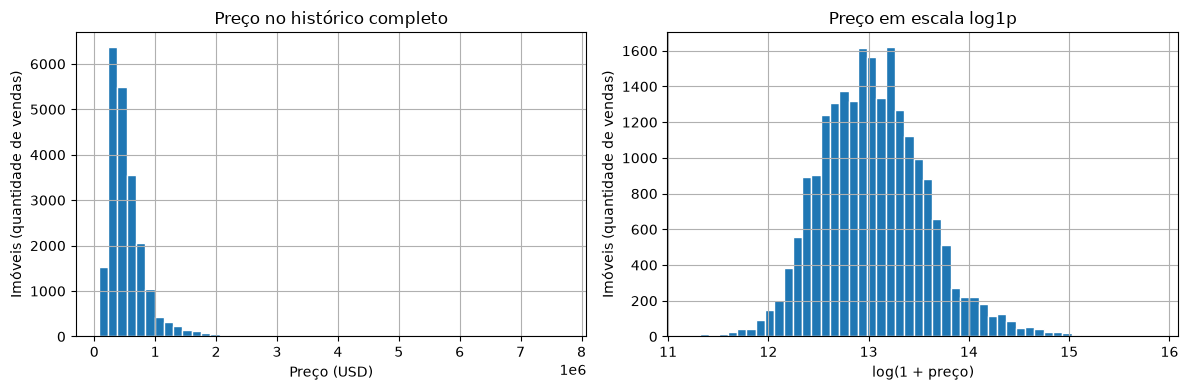

In [16]:
# Mostra os preços em duas escalas.
precos = dados_eda["price"].dropna()
if not (precos.gt(0).all()):
    raise ValueError("Investigar preços antes de usar logaritmo.")
figura, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].hist(precos, bins=50, edgecolor="white")
eixos[0].set(title="Preço no histórico completo", xlabel="Preço (USD)", ylabel="Imóveis (quantidade de vendas)")
eixos[1].hist(np.log1p(precos), bins=50, edgecolor="white")
eixos[1].set(title="Preço em escala log1p", xlabel="log(1 + preço)", ylabel="Imóveis (quantidade de vendas)")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_price_distribution.png", dpi=150)
plt.show()

**O que o resultado mostra**

A maior parte dos preços está nas faixas menores, enquanto poucas vendas caras alongam o gráfico. A escala log1p à direita comprime valores elevados e facilita ver a distribuição.

**Por que fizemos esta análise e o que decidimos**

As duas escalas evitam que os imóveis mais caros escondam o restante do conjunto. O eixo transformado não é preço direto: mostra log(1 + preço). Usar essa transformação no modelo ainda dependerá de comparação na validação.

In [17]:
# Calcula medidas centrais e identifica extremos.
primeiro_quartil, terceiro_quartil = precos.quantile([0.25, 0.75])
intervalo_central = terceiro_quartil - primeiro_quartil
precos_extremos = (precos < primeiro_quartil - 1.5 * intervalo_central) | (precos > terceiro_quartil + 1.5 * intervalo_central)
print("Mediana:", round(precos.median(), 2))
print("Média:", round(precos.mean(), 2))
print("Assimetria amostral:", round(precos.skew(), 3))
print("Extremos pela regra IQR:", int(precos_extremos.sum()))

Mediana: 450000.0
Média: 540088.14
Assimetria amostral: 4.024
Extremos pela regra IQR: 1146


**O que o resultado mostra**

No histórico completo, a média é 540.088,14 e a mediana é 450.000,00. A assimetria é 4,024 e a regra sinalizou 1.146 preços extremos.

**Por que fizemos esta análise e o que decidimos**

Vendas muito caras elevam a média. A mediana representa o centro com menor influência desses valores. A regra usa a distância entre os percentis 25% e 75% e amplia os limites em 1,5 vez essa distância. Um valor fora do intervalo não é necessariamente erro; os registros são preservados.

In [18]:
# Examina as características das vendas mais caras.
exibir(dados_eda.nlargest(10, "price")[["id", "price", "sqft_living", "bedrooms", "grade", "zipcode"]])

,id,price,sqft_living,bedrooms,grade,zipcode
7252,6762700020,7700000.0,12050,6,13,98102
3914,9808700762,7062500.0,10040,5,11,98004
9254,9208900037,6885000.0,9890,6,13,98039
4411,2470100110,5570000.0,9200,5,13,98039
1448,8907500070,5350000.0,8000,5,12,98004
1315,7558700030,5300000.0,7390,6,12,98040
1164,1247600105,5110800.0,8010,5,12,98033
8092,1924059029,4668000.0,9640,5,12,98040
2626,7738500731,4500000.0,6640,5,12,98155
8638,3835500195,4489000.0,6430,4,12,98004


**O que o resultado mostra**

As dez maiores vendas têm áreas habitáveis altas e grade de 11 a 13. O preço máximo é 7.700.000.

**Por que fizemos esta análise e o que decidimos**

Procuramos contexto para os extremos. Área e possível padrão construtivo podem ajudar a explicar preços elevados, mas não confirmam sua validade. Apagar essas linhas apenas pelo preço poderia remover imóveis reais relevantes para o negócio.

## 6. Quais características acompanham preços maiores ou menores?

Vamos procurar associações entre valores. Duas características variarem juntas não prova que uma causa a outra.

In [19]:
# Mede associações das características com preço.
correlacoes = pd.DataFrame({
    "pearson": dados_numericos.corr(method="pearson")["price"],
    "spearman": dados_numericos.corr(method="spearman")["price"],
}).drop(index="price").sort_values("spearman", ascending=False)
exibir(correlacoes)
correlacoes.to_csv(PASTA_RESULTADOS / "eda_price_correlations.csv")

,pearson,spearman
grade,0.667434,0.658215
sqft_living,0.702035,0.644191
sqft_living15,0.585379,0.572290
sqft_above,0.605567,0.541752
bathrooms,0.525138,0.497160
lat,0.307003,0.456409
bedrooms,0.308350,0.344652
floors,0.256794,0.322347
view,0.397293,0.293931
sqft_basement,0.323816,0.251704


**O que o resultado mostra**

As associações de Spearman com preço são 0,658 para grade, 0,644 para área habitável e 0,572 para sqft_living15. Valores maiores tendem a acompanhar preços maiores no histórico completo.

**Por que fizemos esta análise e o que decidimos**

Pearson resume uma relação próxima de uma linha reta; Spearman observa a ordem dos valores. As medidas vão de −1 a 1 e não representam percentual de acerto ou aumento no preço. Usamos a comparação para levantar hipóteses, sem concluir causalidade nem selecionar automaticamente as colunas do modelo.

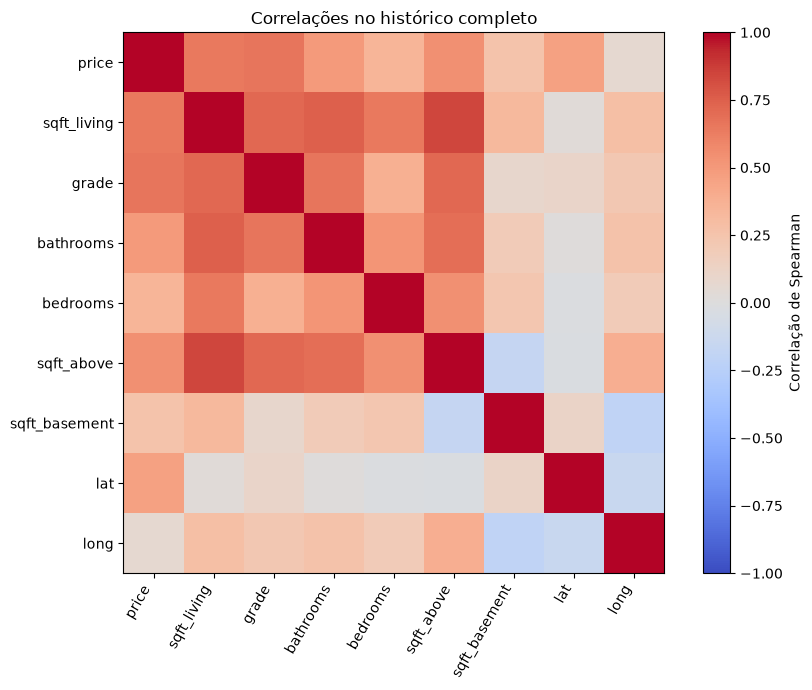

In [20]:
# Compara associações entre pares de colunas.
colunas_selecionadas = ["price", "sqft_living", "grade", "bathrooms", "bedrooms",
            "sqft_above", "sqft_basement", "lat", "long"]
matriz_correlacoes = dados_eda[colunas_selecionadas].corr(method="spearman")
figura, eixo = plt.subplots(figsize=(9, 7))
mapa_cores = eixo.imshow(matriz_correlacoes, cmap="coolwarm", vmin=-1, vmax=1)
eixo.set_xticks(range(len(colunas_selecionadas)), colunas_selecionadas, rotation=60, ha="right")
eixo.set_yticks(range(len(colunas_selecionadas)), colunas_selecionadas)
eixo.grid(False)
figura.colorbar(mapa_cores, ax=eixo, label="Correlação de Spearman")
eixo.set_title("Correlações no histórico completo")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_correlations.png", dpi=150)
plt.show()

**O que o resultado mostra**

As cores representam associações entre pares de características. Valores próximos de 1 indicam crescimento conjunto; próximos de −1, sentidos opostos; próximos de zero, pouca associação por essa medida. A diagonal compara cada coluna consigo mesma.

**Por que fizemos esta análise e o que decidimos**

Esse quadro ajuda a procurar colunas que carregam informações parecidas, como medidas de área. Mais colunas semelhantes não garantem mais informação. Qualquer exclusão será avaliada na validação, não decidida apenas pela cor.

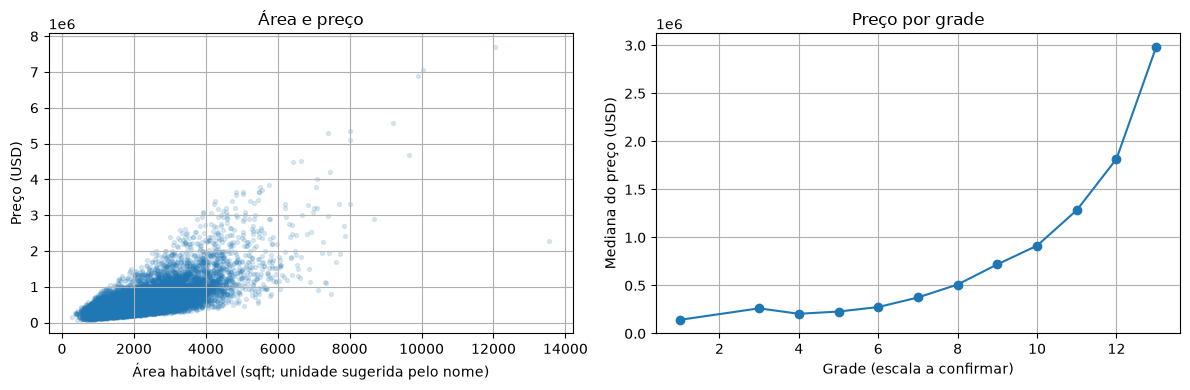

In [21]:
# Relaciona preço com área e classificação.
# Usa todos os registros do histórico completo, com transparência.
figura, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].scatter(dados_eda["sqft_living"], dados_eda["price"], alpha=0.15, s=8)
eixos[0].set(xlabel="Área habitável (sqft; unidade sugerida pelo nome)",
            ylabel="Preço (USD)", title="Área e preço")
resumo_padrao_construtivo = dados_eda.groupby("grade")["price"].agg(["median", "count"])
eixos[1].plot(resumo_padrao_construtivo.index, resumo_padrao_construtivo["median"], marker="o")
eixos[1].set(xlabel="Grade (escala a confirmar)", ylabel="Mediana do preço (USD)",
            title="Preço por grade")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_area_grade.png", dpi=150)
plt.show()

**O que o resultado mostra**

Imóveis maiores tendem a custar mais, mas existem preços diferentes para áreas semelhantes. A mediana cresce nos grupos grade de 4 a 13; nos grupos menores a sequência não é regular.

**Por que fizemos esta análise e o que decidimos**

Os gráficos mostram que uma característica não explica todo o preço. A linha entre categorias facilita comparar medianas e não é uma fórmula de previsão. O número de vendas de cada grupo precisa ser considerado antes de generalizar.

In [22]:
# Conta exemplos por classificação de construção.
exibir(resumo_padrao_construtivo)

,median,count
grade,,
1,142000.0,1
3,262000.0,3
4,205000.0,29
5,228700.0,242
6,275276.5,2038
7,375000.0,8981
8,510000.0,6068
9,720000.0,2615
10,914327.0,1134


**O que o resultado mostra**

Grade 7 e 8 têm 8.981 e 6.068 vendas; grade 13 tem 13. Os grupos 1 e 3 têm 1 e 3. Median significa preço mediano e count é quantidade de vendas.

**Por que fizemos esta análise e o que decidimos**

Mostramos o tamanho dos grupos porque uma mediana baseada em poucos imóveis tem apoio muito menor nesta amostra. Categorias raras precisam de cuidado na apresentação e na futura avaliação do modelo.

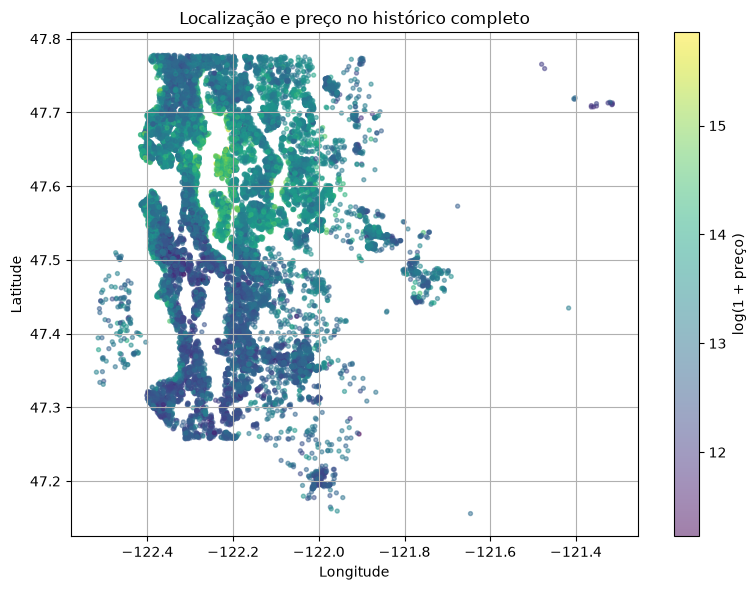

In [23]:
# Mostra localização e preço por cor.
figura, eixo = plt.subplots(figsize=(8, 6))
pontos = eixo.scatter(dados_eda["long"], dados_eda["lat"],
                    c=np.log1p(dados_eda["price"]), cmap="viridis", s=8, alpha=0.5)
eixo.set(xlabel="Longitude", ylabel="Latitude", title="Localização e preço no histórico completo")
figura.colorbar(pontos, ax=eixo, label="log(1 + preço)")
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "eda_location.png", dpi=150)
plt.show()

**O que o resultado mostra**

Cada ponto é uma venda localizada por latitude e longitude; a cor indica preço em escala logarítmica. O gráfico permite comparar os valores nas posições registradas.

**Por que fizemos esta análise e o que decidimos**

Investigamos onde há exemplos e possíveis diferenças espaciais. Sem limites de bairros ou mapa de referência, não atribuiremos nomes de regiões nem causas. A presença de dados nesses locais não garante desempenho em outras regiões.

## 7. O que sabemos sobre as regiões dos imóveis?

Cada CEP contará uma vez nesta descrição. Ainda não juntamos indicadores e preços para medir o benefício dessas informações. Fonte, unidades e datas continuam pendentes.

In [24]:
# Resume a demografia contando cada CEP uma vez.
demografia_eda = demografia[
    demografia["zipcode"].isin(dados_eda["zipcode"])
].copy()
exibir(demografia_eda.select_dtypes(include="number").describe().T)

,count,mean,std,min,25%,50%,75%,max
ppltn_qty,70.0,25655.242857,11550.597239,3037.0,19449.50,23926.5,31013.75,64181.0
urbn_ppltn_qty,70.0,24543.814286,12613.622494,0.0,18943.50,23298.0,30773.50,64181.0
sbrbn_ppltn_qty,70.0,192.457143,1359.783707,0.0,0.00,0.0,0.00,11176.0
farm_ppltn_qty,70.0,16.442857,59.566948,0.0,0.00,0.0,0.00,439.0
non_farm_qty,70.0,866.614286,2007.028175,0.0,0.00,0.0,313.00,9973.0
medn_hshld_incm_amt,70.0,57530.785714,16166.136140,32085.0,46397.75,56933.0,63599.50,132665.0
medn_incm_per_prsn_amt,70.0,30623.342857,10256.973419,17087.0,24422.00,27639.5,35207.25,81926.0
hous_val_amt,70.0,263954.285714,107660.168762,141500.0,193225.00,239850.0,288925.00,790300.0
edctn_less_than_9_qty,70.0,633.614286,653.259925,4.0,200.00,406.0,899.75,3671.0
edctn_9_12_qty,70.0,1472.514286,989.467354,51.0,707.75,1213.0,1933.75,4483.0


**O que o resultado mostra**

Os 70 CEPs estão presentes no histórico completo. O possível indicador de renda domiciliar mediana varia de 32.085 a 132.665; moeda e período ainda não foram confirmados.

**Por que fizemos esta análise e o que decidimos**

Cada CEP conta uma vez, evitando dar mais peso a regiões com mais vendas. Há diferenças a investigar, mas ainda não medimos o ganho para prever preços. Um indicador regional não descreve necessariamente um morador ou imóvel individual.

In [25]:
# Procura colunas sem variação.
colunas_constantes = [
    coluna for coluna in demografia_eda.columns
    if demografia_eda[coluna].nunique(dropna=False) <= 1
]
print("Colunas constantes nos CEPs do histórico completo:", colunas_constantes)

Colunas constantes nos CEPs do histórico completo: []


**O que o resultado mostra**

A lista vazia significa que nenhuma coluna tem o mesmo valor em todos os CEPs examinados.

**Por que fizemos esta análise e o que decidimos**

Uma característica idêntica em todas as linhas não distingue esses exemplos. Esta é apenas uma triagem: variar não prova que a informação seja útil, correta ou disponível no momento da previsão.

In [26]:
# Confere limites dos possíveis percentuais.
colunas_percentuais = [coluna for coluna in demografia if coluna.startswith("per_")]
print("Percentuais fora de 0 a 100 (hipótese de unidade):")
exibir(((demografia_eda[colunas_percentuais] < 0) |
         (demografia_eda[colunas_percentuais] > 100)).sum().to_frame("registros"))
print("Verificar fonte, denominadores e ano de referência antes da modelagem.")

Percentuais fora de 0 a 100 (hipótese de unidade):


,registros
per_urbn,0
per_sbrbn,0
per_farm,0
per_non_farm,0
per_less_than_9,0
per_9_to_12,0
per_hsd,0
per_some_clg,0
per_assoc,0
per_bchlr,0


Verificar fonte, denominadores e ano de referência antes da modelagem.


**O que o resultado mostra**

Nenhum valor das colunas per_ ficou fora do intervalo entre 0 e 100. O resultado é compatível com a hipótese de percentuais.

**Por que fizemos esta análise e o que decidimos**

Esse limite detectaria proporções usuais impossíveis, como −5% ou 150%. Passar na checagem não confirma denominadores, categorias ou ano. 

## 8. Síntese e próximos passos

Salvamos os achados do histórico completo. O próximo passo é o merge por CEP e uma EDA complementar das informações combinadas. O split será realizado na modelagem.

In [27]:
# Salva uma síntese dos resultados.
caracteristicas_mais_associadas = correlacoes["spearman"].abs().nlargest(3).index.tolist()
resumo_final = {
    "datasets": visao_geral.to_dict(orient="records"),
    "analysis_scope": "full_historical_dataset",
    "historical_rows_analyzed": len(dados_eda),
    "split_status": "pending_modeling_stage",
    "future_feature_matches": quantidade_coincidencias,
    "historical_price_median": float(precos.median()),
    "historical_price_skew": float(precos.skew()),
    "historical_iqr_outliers": int(precos_extremos.sum()),
    "strongest_absolute_spearman": caracteristicas_mais_associadas,
    "quality_flags": {nome: int(selecao_linhas.sum()) for nome, selecao_linhas in verificacoes_qualidade.items()},
}
(PASTA_RESULTADOS / "eda_findings.json").write_text(
    json.dumps(resumo_final, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(json.dumps(resumo_final, indent=2, ensure_ascii=False))

{
  "datasets": [
    {
      "arquivo": "imoveis",
      "linhas": 21613,
      "colunas": 21,
      "celulas_ausentes": 0,
      "linhas_duplicadas": 0
    },
    {
      "arquivo": "demografia",
      "linhas": 70,
      "colunas": 27,
      "celulas_ausentes": 0,
      "linhas_duplicadas": 0
    },
    {
      "arquivo": "futuros",
      "linhas": 100,
      "colunas": 18,
      "celulas_ausentes": 0,
      "linhas_duplicadas": 0
    }
  ],
  "analysis_scope": "full_historical_dataset",
  "historical_rows_analyzed": 21613,
  "split_status": "pending_modeling_stage",
  "future_feature_matches": 100,
  "historical_price_median": 450000.0,
  "historical_price_skew": 4.024069144684714,
  "historical_iqr_outliers": 1146,
  "strongest_absolute_spearman": [
    "grade",
    "sqft_living",
    "sqft_living15"
  ],
  "quality_flags": {
    "preco_nao_positivo": 0,
    "area_habitavel_nao_positiva": 0,
    "terreno_nao_positivo": 0,
    "quartos_zero": 13,
    "banheiros_zero": 10,
    "quar

**O que o resultado mostra**

O resumo reúne as dimensões dos arquivos, as coincidências dos exemplos futuros, as estatísticas de preço e os casos a investigar em todo o histórico. Não há modelo treinado nem partições definidas.

**Por que fizemos esta análise e o que decidimos**

Registramos evidências para as próximas etapas. Seguiremos com merge, EDA pós-merge, preparação das variáveis e, depois, split e modelagem. O uso do histórico completo na exploração será documentado para contextualizar a avaliação.

## Conclusão para apresentação

A EDA descreveu todas as **21.613 vendas**, sem dividir treino, validação ou teste. Não há ausências reconhecidas pelo pandas nem cópias completas, mas existem imóveis repetidos e valores a investigar.

A mediana do preço é **450.000,00** e a regra estatística sinaliza **1.146 extremos**, preservados. USD foi adotado como premissa; parte das definições das colunas e a moeda na fonte ainda precisam ser confirmadas.

Todos os CEPs encontram informações demográficas. Os 100 exemplos futuros coincidem nas características com registros históricos e não constituem evidência independente de desempenho.

**Próximos passos:** merge → EDA complementar → preparação das variáveis → split e modelagem. 